## Import Libraries

In [165]:
# To ignore warnings
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

%matplotlib inline

## Load the Data

In [167]:
df = pd.read_csv("Jarir_laptops1.csv")

In [168]:
df.shape

(205, 40)

In [169]:
df.head(2)

,Product Title,Product Price,Warranty Period (Months),Accesorises warranty,Warranted by,SKU,Manufacturer Number,processor type,NPU (Neural Processing Unit),AI (Artificial Intelligence),...,fingerprint,battery type,width,height/length,depth,weight,card reader,Shipping Weight (kg),Renewed Grade,Renewed Remarks
0,Huawei MateBook 14 Laptop,"4,299",24.0,12 Months,Manufacturer,638525.0,53014ASK,Intel Core Ultra 5 125H,Intel AI Boost,Yes,...,Yes,Lithium Polymer (Li-Po),312.60 mm ( 12.31 in ),226.80 mm ( 8.93 in ),15.90 mm ( .63 in ),1.31 kg ( 2.89 lb ),NaN,NaN,NaN,NaN
1,Apple MacBook Air 15 M3 Laptop,"5,999",24.0,12 Months,Manufacturer,646475.0,MC9D4ABA,M3 8-core CPU,16-core Neural Engine,Yes,...,Yes,Lithium Polymer (Li-Po),34.04 cm ( 13.40 in ),23.76 cm ( 9.35 in ),1.15 cm ( .45 in ),1.51 kg ( 3.33 lb ),NaN,NaN,NaN,NaN


## Preprocess the Data

#### 1. Simple EDA + Data Quality checking

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Product Title                  205 non-null    object 
 1   Product Price                  205 non-null    object 
 2   Warranty Period (Months)       198 non-null    float64
 3   Accesorises warranty           198 non-null    object 
 4   Warranted by                   198 non-null    object 
 5   SKU                            198 non-null    float64
 6   Manufacturer Number            198 non-null    object 
 7   processor type                 198 non-null    object 
 8   NPU (Neural Processing Unit)   113 non-null    object 
 9   AI (Artificial Intelligence)   112 non-null    object 
 10  display type                   198 non-null    object 
 11  graphics card                  198 non-null    object 
 12  display size                   198 non-null    obj

In [173]:
df.shape

(205, 40)

- Uniqueness:

In [175]:
df.duplicated().sum

<bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
200    False
201    False
202    False
203    False
204    False
Length: 205, dtype: bool>

In [176]:
df.drop_duplicates(inplace = True)

In [177]:
df.shape

(200, 40)

- Completeness

In [179]:
# Filtering and displaying rows where 'Product Title' contains "Not available"
not_available_rows = df[df['Product Title'].str.contains("Not available", na=False)]

not_available_rows

,Product Title,Product Price,Warranty Period (Months),Accesorises warranty,Warranted by,SKU,Manufacturer Number,processor type,NPU (Neural Processing Unit),AI (Artificial Intelligence),...,fingerprint,battery type,width,height/length,depth,weight,card reader,Shipping Weight (kg),Renewed Grade,Renewed Remarks
111,Not available,Not available,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
122,Not available,689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [180]:
df['Product Title'].str.contains("Not available", na=False)

0      False
1      False
2      False
3      False
4      False
       ...  
200    False
201    False
202    False
203    False
204    False
Name: Product Title, Length: 200, dtype: bool

In [181]:
df.shape

(200, 40)

In [182]:
# Remove rows where 'Product Title' contains "Not available"
df = df[~df['Product Title'].str.contains("Not available", na=False)]

# Display the first few rows of the updated 'df' to confirm the change
df.head()

,Product Title,Product Price,Warranty Period (Months),Accesorises warranty,Warranted by,SKU,Manufacturer Number,processor type,NPU (Neural Processing Unit),AI (Artificial Intelligence),...,fingerprint,battery type,width,height/length,depth,weight,card reader,Shipping Weight (kg),Renewed Grade,Renewed Remarks
0,Huawei MateBook 14 Laptop,"4,299",24.0,12 Months,Manufacturer,638525.0,53014ASK,Intel Core Ultra 5 125H,Intel AI Boost,Yes,...,Yes,Lithium Polymer (Li-Po),312.60 mm ( 12.31 in ),226.80 mm ( 8.93 in ),15.90 mm ( .63 in ),1.31 kg ( 2.89 lb ),NaN,NaN,NaN,NaN
1,Apple MacBook Air 15 M3 Laptop,"5,999",24.0,12 Months,Manufacturer,646475.0,MC9D4ABA,M3 8-core CPU,16-core Neural Engine,Yes,...,Yes,Lithium Polymer (Li-Po),34.04 cm ( 13.40 in ),23.76 cm ( 9.35 in ),1.15 cm ( .45 in ),1.51 kg ( 3.33 lb ),NaN,NaN,NaN,NaN
2,Apple MacBook Air 15 M3 Laptop,"5,999",24.0,12 Months,Manufacturer,632673.0,MRYR3ABA,M3 8-core CPU,16-core Neural Engine,Yes,...,Yes,Lithium Polymer (Li-Po),34.04 cm ( 13.40 in ),23.76 cm ( 9.35 in ),1.15 cm ( .45 in ),1.51 kg ( 3.33 lb ),NaN,NaN,NaN,NaN
3,Asus Laptop,"3,799",24.0,12 Months,Manufacturer,642879.0,UM3406OLEDR7W,AMD Ryzen 7-8840HS,AMD XDNA up to 16 TOPS,Yes,...,Yes,Lithium Ion (Li-Ion) - 4 Cell,32.24 cm ( 12.69 in ),22.01 cm ( 8.67 in ),1.49 cm ( .59 in ),1.20 kg ( 2.65 lb ),Yes,NaN,NaN,NaN
4,Microsoft Surface Laptop 7 Laptop,"9,699",24.0,Not Applicable,JARIR,639206.0,ZHI00014,Snapdragon X Elite 12 Core,Qualcomm Hexagon NPU 45 TOPS,Yes,...,NaN,Lithium Ion (Li-Ion) - 6 Cell,32.90 cm ( 12.95 in ),23.90 cm ( 9.41 in ),1.80 cm ( .71 in ),1.60 kg ( 3.53 lb ),NaN,NaN,NaN,NaN


In [183]:
df.isnull().sum()

Product Title                      0
Product Price                      0
Warranty Period (Months)           0
Accesorises warranty               0
Warranted by                       0
SKU                                0
Manufacturer Number                0
processor type                     0
NPU (Neural Processing Unit)      85
AI (Artificial Intelligence)      86
display type                       0
graphics card                      0
display size                       0
operating system                   0
product type                       0
model/chipset number             115
model series                       0
generation/release                 0
color                              1
operating system architecture    100
processor speed                   94
capacity                           0
RAM                                0
connectivity technology            0
ports                              2
touch display                    176
display resolution                 0
c

In [184]:
# Replacing 'Not available' with NaN, then removing commas and converting to float
df['Product Price'] = pd.to_numeric(df['Product Price'].str.replace('٫', '').str.replace(',', ''), errors='coerce')

# Displaying the first few rows to confirm the change
df.head()


,Product Title,Product Price,Warranty Period (Months),Accesorises warranty,Warranted by,SKU,Manufacturer Number,processor type,NPU (Neural Processing Unit),AI (Artificial Intelligence),...,fingerprint,battery type,width,height/length,depth,weight,card reader,Shipping Weight (kg),Renewed Grade,Renewed Remarks
0,Huawei MateBook 14 Laptop,4299,24.0,12 Months,Manufacturer,638525.0,53014ASK,Intel Core Ultra 5 125H,Intel AI Boost,Yes,...,Yes,Lithium Polymer (Li-Po),312.60 mm ( 12.31 in ),226.80 mm ( 8.93 in ),15.90 mm ( .63 in ),1.31 kg ( 2.89 lb ),NaN,NaN,NaN,NaN
1,Apple MacBook Air 15 M3 Laptop,5999,24.0,12 Months,Manufacturer,646475.0,MC9D4ABA,M3 8-core CPU,16-core Neural Engine,Yes,...,Yes,Lithium Polymer (Li-Po),34.04 cm ( 13.40 in ),23.76 cm ( 9.35 in ),1.15 cm ( .45 in ),1.51 kg ( 3.33 lb ),NaN,NaN,NaN,NaN
2,Apple MacBook Air 15 M3 Laptop,5999,24.0,12 Months,Manufacturer,632673.0,MRYR3ABA,M3 8-core CPU,16-core Neural Engine,Yes,...,Yes,Lithium Polymer (Li-Po),34.04 cm ( 13.40 in ),23.76 cm ( 9.35 in ),1.15 cm ( .45 in ),1.51 kg ( 3.33 lb ),NaN,NaN,NaN,NaN
3,Asus Laptop,3799,24.0,12 Months,Manufacturer,642879.0,UM3406OLEDR7W,AMD Ryzen 7-8840HS,AMD XDNA up to 16 TOPS,Yes,...,Yes,Lithium Ion (Li-Ion) - 4 Cell,32.24 cm ( 12.69 in ),22.01 cm ( 8.67 in ),1.49 cm ( .59 in ),1.20 kg ( 2.65 lb ),Yes,NaN,NaN,NaN
4,Microsoft Surface Laptop 7 Laptop,9699,24.0,Not Applicable,JARIR,639206.0,ZHI00014,Snapdragon X Elite 12 Core,Qualcomm Hexagon NPU 45 TOPS,Yes,...,NaN,Lithium Ion (Li-Ion) - 6 Cell,32.90 cm ( 12.95 in ),23.90 cm ( 9.41 in ),1.80 cm ( .71 in ),1.60 kg ( 3.53 lb ),NaN,NaN,NaN,NaN


In [185]:
df['Product Price']

0      4299
1      5999
2      5999
3      3799
4      9699
       ... 
200    5199
201    5029
202    2799
203    2499
204    5799
Name: Product Price, Length: 198, dtype: int64

In [186]:
df['display size']

0      14.2"
1      15.3"
2      15.3"
3        14"
4        15"
       ...  
200    13.6"
201      16"
202      14"
203    15.6"
204    15.3"
Name: display size, Length: 198, dtype: object

In [187]:
df.shape

(198, 40)

In [188]:
# Filling null values in the specified columns with "No"
df[['fingerprint', 'card reader', 'touch display', 'AI (Artificial Intelligence)']] = df[
    ['fingerprint', 'card reader', 'touch display', 'AI (Artificial Intelligence)']
].fillna("No")

# Displaying the first few rows to confirm the changes
df.head()

,Product Title,Product Price,Warranty Period (Months),Accesorises warranty,Warranted by,SKU,Manufacturer Number,processor type,NPU (Neural Processing Unit),AI (Artificial Intelligence),...,fingerprint,battery type,width,height/length,depth,weight,card reader,Shipping Weight (kg),Renewed Grade,Renewed Remarks
0,Huawei MateBook 14 Laptop,4299,24.0,12 Months,Manufacturer,638525.0,53014ASK,Intel Core Ultra 5 125H,Intel AI Boost,Yes,...,Yes,Lithium Polymer (Li-Po),312.60 mm ( 12.31 in ),226.80 mm ( 8.93 in ),15.90 mm ( .63 in ),1.31 kg ( 2.89 lb ),No,NaN,NaN,NaN
1,Apple MacBook Air 15 M3 Laptop,5999,24.0,12 Months,Manufacturer,646475.0,MC9D4ABA,M3 8-core CPU,16-core Neural Engine,Yes,...,Yes,Lithium Polymer (Li-Po),34.04 cm ( 13.40 in ),23.76 cm ( 9.35 in ),1.15 cm ( .45 in ),1.51 kg ( 3.33 lb ),No,NaN,NaN,NaN
2,Apple MacBook Air 15 M3 Laptop,5999,24.0,12 Months,Manufacturer,632673.0,MRYR3ABA,M3 8-core CPU,16-core Neural Engine,Yes,...,Yes,Lithium Polymer (Li-Po),34.04 cm ( 13.40 in ),23.76 cm ( 9.35 in ),1.15 cm ( .45 in ),1.51 kg ( 3.33 lb ),No,NaN,NaN,NaN
3,Asus Laptop,3799,24.0,12 Months,Manufacturer,642879.0,UM3406OLEDR7W,AMD Ryzen 7-8840HS,AMD XDNA up to 16 TOPS,Yes,...,Yes,Lithium Ion (Li-Ion) - 4 Cell,32.24 cm ( 12.69 in ),22.01 cm ( 8.67 in ),1.49 cm ( .59 in ),1.20 kg ( 2.65 lb ),Yes,NaN,NaN,NaN
4,Microsoft Surface Laptop 7 Laptop,9699,24.0,Not Applicable,JARIR,639206.0,ZHI00014,Snapdragon X Elite 12 Core,Qualcomm Hexagon NPU 45 TOPS,Yes,...,No,Lithium Ion (Li-Ion) - 6 Cell,32.90 cm ( 12.95 in ),23.90 cm ( 9.41 in ),1.80 cm ( .71 in ),1.60 kg ( 3.53 lb ),No,NaN,NaN,NaN


- Check Accuracy

In [190]:
# Accurecy types
df.shape

(198, 40)

In [191]:
df.isnull().sum()

Product Title                      0
Product Price                      0
Warranty Period (Months)           0
Accesorises warranty               0
Warranted by                       0
SKU                                0
Manufacturer Number                0
processor type                     0
NPU (Neural Processing Unit)      85
AI (Artificial Intelligence)       0
display type                       0
graphics card                      0
display size                       0
operating system                   0
product type                       0
model/chipset number             115
model series                       0
generation/release                 0
color                              1
operating system architecture    100
processor speed                   94
capacity                           0
RAM                                0
connectivity technology            0
ports                              2
touch display                      0
display resolution                 0
c

In [192]:
# Filling null values in object-type columns with "Not Applicable"
df = df.fillna({col: "Not Applicable" for col in df.select_dtypes(include='object').columns})

# Displaying the first few rows to confirm the changes
df.head()

,Product Title,Product Price,Warranty Period (Months),Accesorises warranty,Warranted by,SKU,Manufacturer Number,processor type,NPU (Neural Processing Unit),AI (Artificial Intelligence),...,fingerprint,battery type,width,height/length,depth,weight,card reader,Shipping Weight (kg),Renewed Grade,Renewed Remarks
0,Huawei MateBook 14 Laptop,4299,24.0,12 Months,Manufacturer,638525.0,53014ASK,Intel Core Ultra 5 125H,Intel AI Boost,Yes,...,Yes,Lithium Polymer (Li-Po),312.60 mm ( 12.31 in ),226.80 mm ( 8.93 in ),15.90 mm ( .63 in ),1.31 kg ( 2.89 lb ),No,NaN,Not Applicable,NaN
1,Apple MacBook Air 15 M3 Laptop,5999,24.0,12 Months,Manufacturer,646475.0,MC9D4ABA,M3 8-core CPU,16-core Neural Engine,Yes,...,Yes,Lithium Polymer (Li-Po),34.04 cm ( 13.40 in ),23.76 cm ( 9.35 in ),1.15 cm ( .45 in ),1.51 kg ( 3.33 lb ),No,NaN,Not Applicable,NaN
2,Apple MacBook Air 15 M3 Laptop,5999,24.0,12 Months,Manufacturer,632673.0,MRYR3ABA,M3 8-core CPU,16-core Neural Engine,Yes,...,Yes,Lithium Polymer (Li-Po),34.04 cm ( 13.40 in ),23.76 cm ( 9.35 in ),1.15 cm ( .45 in ),1.51 kg ( 3.33 lb ),No,NaN,Not Applicable,NaN
3,Asus Laptop,3799,24.0,12 Months,Manufacturer,642879.0,UM3406OLEDR7W,AMD Ryzen 7-8840HS,AMD XDNA up to 16 TOPS,Yes,...,Yes,Lithium Ion (Li-Ion) - 4 Cell,32.24 cm ( 12.69 in ),22.01 cm ( 8.67 in ),1.49 cm ( .59 in ),1.20 kg ( 2.65 lb ),Yes,NaN,Not Applicable,NaN
4,Microsoft Surface Laptop 7 Laptop,9699,24.0,Not Applicable,JARIR,639206.0,ZHI00014,Snapdragon X Elite 12 Core,Qualcomm Hexagon NPU 45 TOPS,Yes,...,No,Lithium Ion (Li-Ion) - 6 Cell,32.90 cm ( 12.95 in ),23.90 cm ( 9.41 in ),1.80 cm ( .71 in ),1.60 kg ( 3.53 lb ),No,NaN,Not Applicable,NaN


In [193]:
# Dropping the specified columns
df = df.drop(columns=['Shipping Weight (kg)', 'Renewed Grade', 'Renewed Remarks' , 'model/chipset number'])

# Displaying the first few rows to confirm the columns have been dropped
df.head()

,Product Title,Product Price,Warranty Period (Months),Accesorises warranty,Warranted by,SKU,Manufacturer Number,processor type,NPU (Neural Processing Unit),AI (Artificial Intelligence),...,cam resolution,multimedia features,special features,fingerprint,battery type,width,height/length,depth,weight,card reader
0,Huawei MateBook 14 Laptop,4299,24.0,12 Months,Manufacturer,638525.0,53014ASK,Intel Core Ultra 5 125H,Intel AI Boost,Yes,...,FHD (2 MP) Webcam,Built-in Mic/Speakers,Full Size Keyboard,Yes,Lithium Polymer (Li-Po),312.60 mm ( 12.31 in ),226.80 mm ( 8.93 in ),15.90 mm ( .63 in ),1.31 kg ( 2.89 lb ),No
1,Apple MacBook Air 15 M3 Laptop,5999,24.0,12 Months,Manufacturer,646475.0,MC9D4ABA,M3 8-core CPU,16-core Neural Engine,Yes,...,1080p FaceTime HD Camera,Built-in Mic/Speakers,Not Applicable,Yes,Lithium Polymer (Li-Po),34.04 cm ( 13.40 in ),23.76 cm ( 9.35 in ),1.15 cm ( .45 in ),1.51 kg ( 3.33 lb ),No
2,Apple MacBook Air 15 M3 Laptop,5999,24.0,12 Months,Manufacturer,632673.0,MRYR3ABA,M3 8-core CPU,16-core Neural Engine,Yes,...,1080p FaceTime HD Camera,Built-in Mic/Speakers,Not Applicable,Yes,Lithium Polymer (Li-Po),34.04 cm ( 13.40 in ),23.76 cm ( 9.35 in ),1.15 cm ( .45 in ),1.51 kg ( 3.33 lb ),No
3,Asus Laptop,3799,24.0,12 Months,Manufacturer,642879.0,UM3406OLEDR7W,AMD Ryzen 7-8840HS,AMD XDNA up to 16 TOPS,Yes,...,1080P FHD Camera,Harman Kardon,Backlit Chiclet Keyboard,Yes,Lithium Ion (Li-Ion) - 4 Cell,32.24 cm ( 12.69 in ),22.01 cm ( 8.67 in ),1.49 cm ( .59 in ),1.20 kg ( 2.65 lb ),Yes
4,Microsoft Surface Laptop 7 Laptop,9699,24.0,Not Applicable,JARIR,639206.0,ZHI00014,Snapdragon X Elite 12 Core,Qualcomm Hexagon NPU 45 TOPS,Yes,...,1080P FHD Camera,Not Applicable,CoPilot+,No,Lithium Ion (Li-Ion) - 6 Cell,32.90 cm ( 12.95 in ),23.90 cm ( 9.41 in ),1.80 cm ( .71 in ),1.60 kg ( 3.53 lb ),No


In [194]:
df.columns

Index(['Product Title', 'Product Price', 'Warranty Period (Months)',
       'Accesorises warranty', 'Warranted by', 'SKU', 'Manufacturer Number',
       'processor type', 'NPU (Neural Processing Unit)',
       'AI (Artificial Intelligence)', 'display type', 'graphics card',
       'display size', 'operating system', 'product type', 'model series',
       'generation/release', 'color', 'operating system architecture',
       'processor speed', 'capacity', 'RAM', 'connectivity technology',
       'ports', 'touch display', 'display resolution', 'cam resolution',
       'multimedia features', 'special features', 'fingerprint',
       'battery type', 'width', 'height/length', 'depth', 'weight',
       'card reader'],
      dtype='object')

In [195]:
# Selecting numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:\n", numerical_columns)

# Selecting categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
print("Categorical columns:\n", categorical_columns)

Numerical columns:
 Index(['Product Price', 'Warranty Period (Months)', 'SKU',
       'generation/release'],
      dtype='object')
Categorical columns:
 Index(['Product Title', 'Accesorises warranty', 'Warranted by',
       'Manufacturer Number', 'processor type', 'NPU (Neural Processing Unit)',
       'AI (Artificial Intelligence)', 'display type', 'graphics card',
       'display size', 'operating system', 'product type', 'model series',
       'color', 'operating system architecture', 'processor speed', 'capacity',
       'RAM', 'connectivity technology', 'ports', 'touch display',
       'display resolution', 'cam resolution', 'multimedia features',
       'special features', 'fingerprint', 'battery type', 'width',
       'height/length', 'depth', 'weight', 'card reader'],
      dtype='object')


In [196]:
# Assuming you have loaded your data into a DataFrame named 'df'
# Rename the column "Product Title" to "Product Name"
df.rename(columns={"Product Title": "Product Name"}, inplace=True)

# Remove the word "Laptop" from each product name
df["Product Name"] = df["Product Name"].str.replace("Laptop", "", regex=False).str.strip()

# Display the updated DataFrame
print(df)

                Product Name  Product Price  Warranty Period (Months)  \
0         Huawei MateBook 14           4299                      24.0   
1    Apple MacBook Air 15 M3           5999                      24.0   
2    Apple MacBook Air 15 M3           5999                      24.0   
3                       Asus           3799                      24.0   
4       Microsoft Surface  7           9699                      24.0   
..                       ...            ...                       ...   
200  Apple MacBook Air 13 M3           5199                      24.0   
201     Lenovo IdeaPad Pro 5           5029                      24.0   
202     Huawei MateBook D 14           2799                      24.0   
203         Dell Vostro 3520           2499                      24.0   
204  Apple MacBook Air 15 M2           5799                      24.0   

    Accesorises warranty  Warranted by       SKU Manufacturer Number  \
0              12 Months  Manufacturer  638525.0   

- check outliers 

- check outliers 'Product Price'

In [199]:
df['Product Price'].value_counts()

Product Price
4499    12
5199     9
5999     9
2999     8
7899     7
        ..
9029     1
3029     1
6519     1
6229     1
2829     1
Name: count, Length: 90, dtype: int64

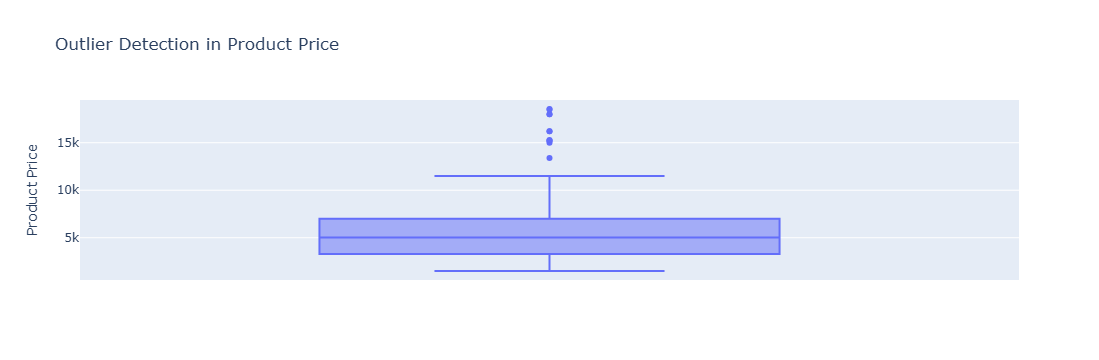

In [200]:
import plotly.express as px

# Creating a box plot to check for outliers in the 'Product Price' column
fig = px.box(df, y='Product Price', title='Outlier Detection in Product Price')
fig.show()


In [201]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['Product Price'].quantile(0.25)
Q3 = df['Product Price'].quantile(0.75)

# Calculate the IQR by subtracting Q1 from Q3
IQR = Q3 - Q1

# Define the lower and upper bounds for the outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# # Filter out outliers
df[(df['Product Price'] < lower_bound) | (df['Product Price'] > upper_bound)]

# Keep only rows that are not outliers
df = df[(df['Product Price'] >= lower_bound) & (df['Product Price'] <= upper_bound)]

- corr

- Univariate Analysis

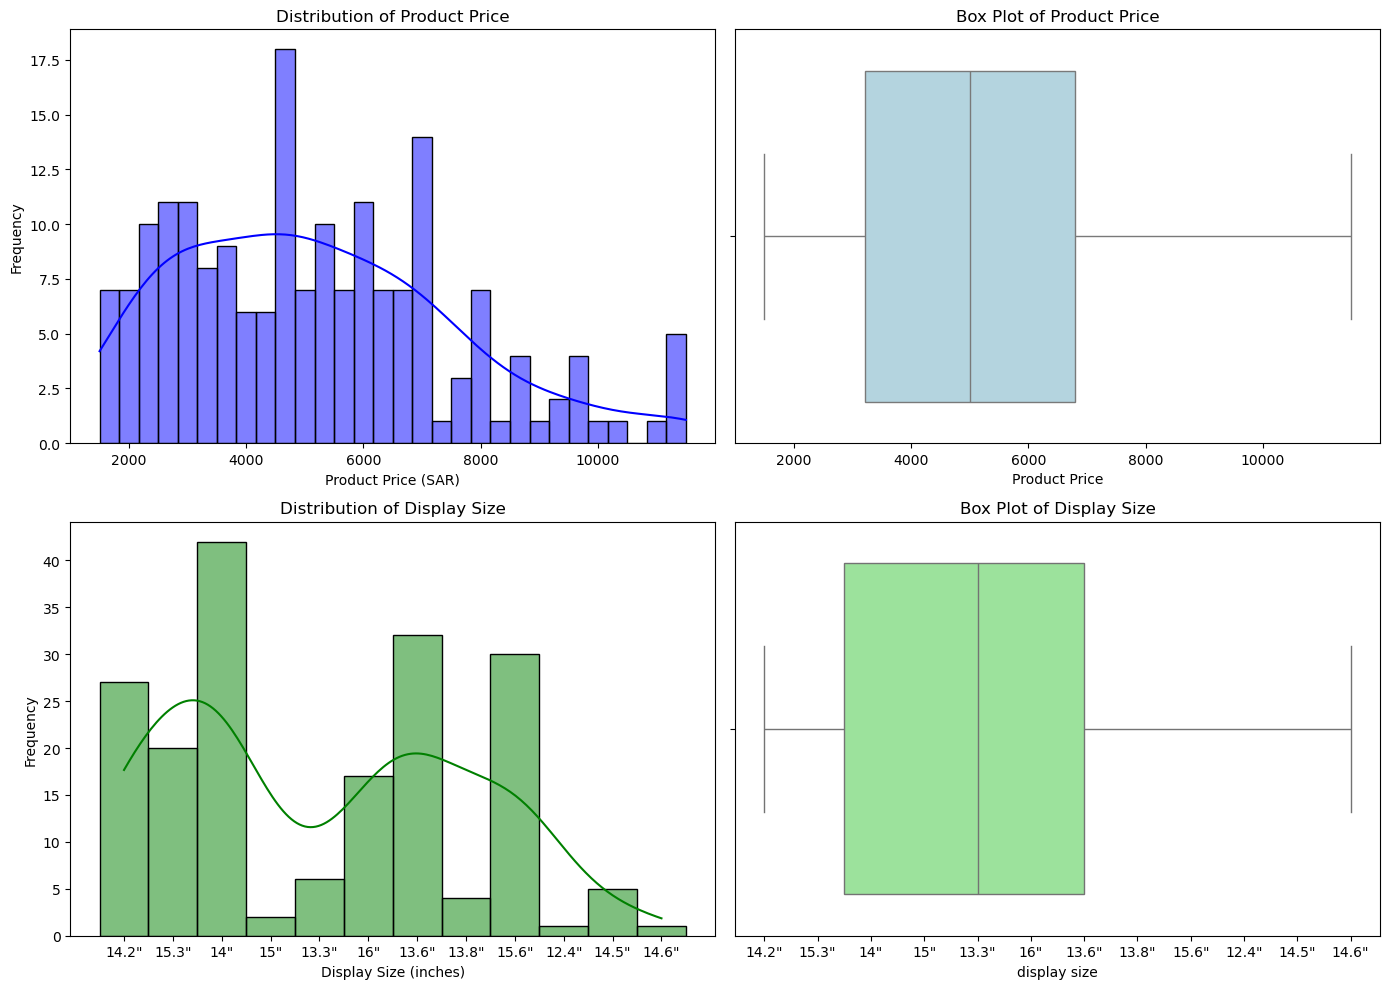

,Product Price
count,187.000000
mean,5167.021390
std,2369.150031
min,1499.000000
25%,3214.000000
50%,4999.000000
75%,6799.000000
max,11499.000000


In [204]:
# Setting up the figure for visualizations
plt.figure(figsize=(14, 10))

# Univariate Analysis for 'Product Price'
plt.subplot(2, 2, 1)
sns.histplot(df['Product Price'].dropna(), kde=True, bins=30, color='blue')
plt.title('Distribution of Product Price')
plt.xlabel('Product Price (SAR)')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['Product Price'], color='lightblue')
plt.title('Box Plot of Product Price')

# Univariate Analysis for 'display size'
plt.subplot(2, 2, 3)
sns.histplot(df['display size'].dropna(), kde=True, bins=20, color='green')
plt.title('Distribution of Display Size')
plt.xlabel('Display Size (inches)')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
sns.boxplot(x=df['display size'], color='lightgreen')
plt.title('Box Plot of Display Size')

plt.tight_layout()
plt.show()

# Calculating the statistical summary for 'Product Price' and 'display size'
stats_summary = df[['Product Price', 'display size']].describe()
stats_summary


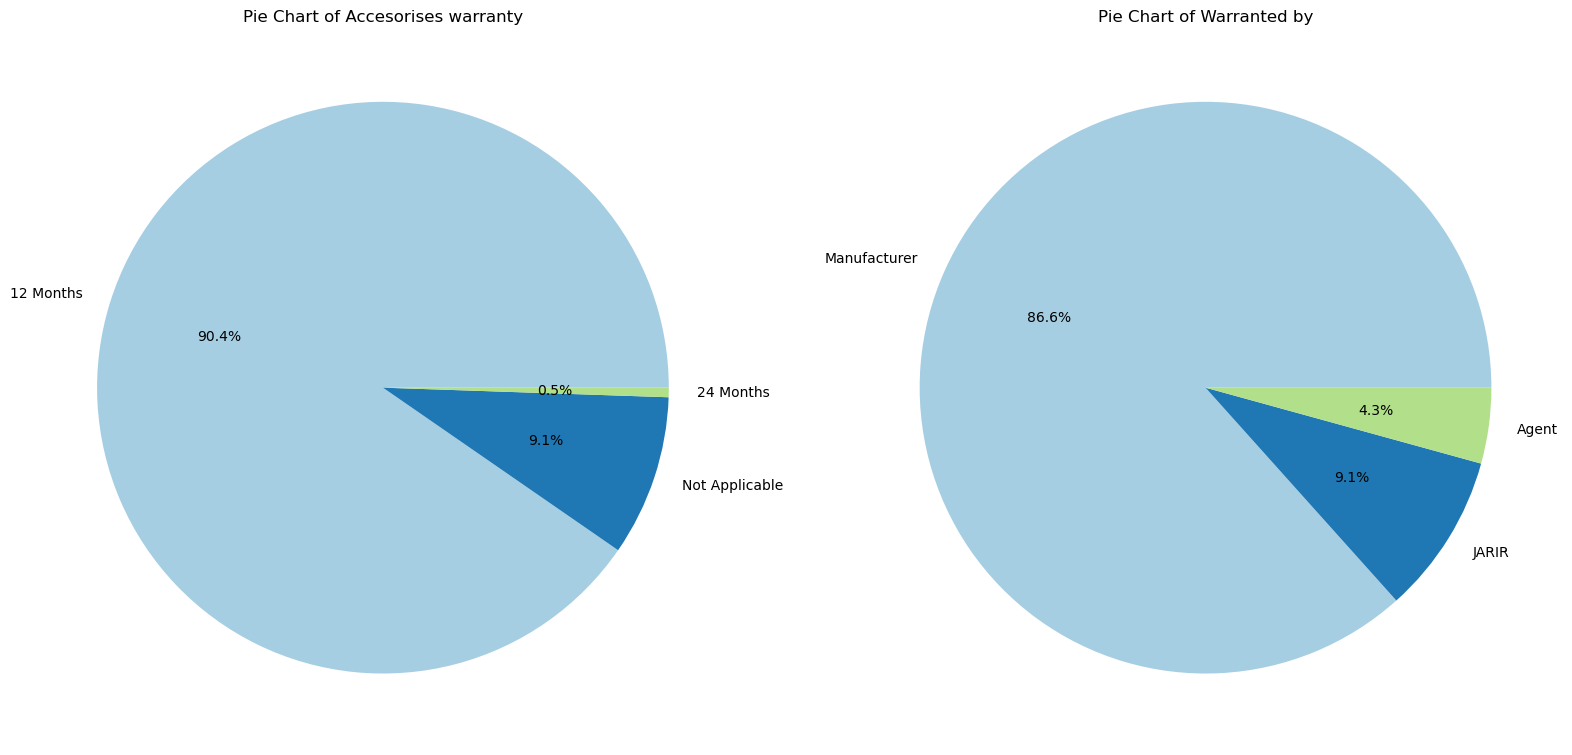

In [205]:
# Creating pie charts for categorical variables with fewer unique categories
plt.figure(figsize=(16, 8))

# Filtering categorical columns with a manageable number of unique categories for pie charts
for i, col in enumerate(['Accesorises warranty', 'Warranted by']):
    plt.subplot(1, 2, i + 1)
    value_counts = df[col].value_counts()
    plt.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', colors=plt.cm.Paired.colors)
    plt.title(f'Pie Chart of {col}')

plt.tight_layout()
plt.show()


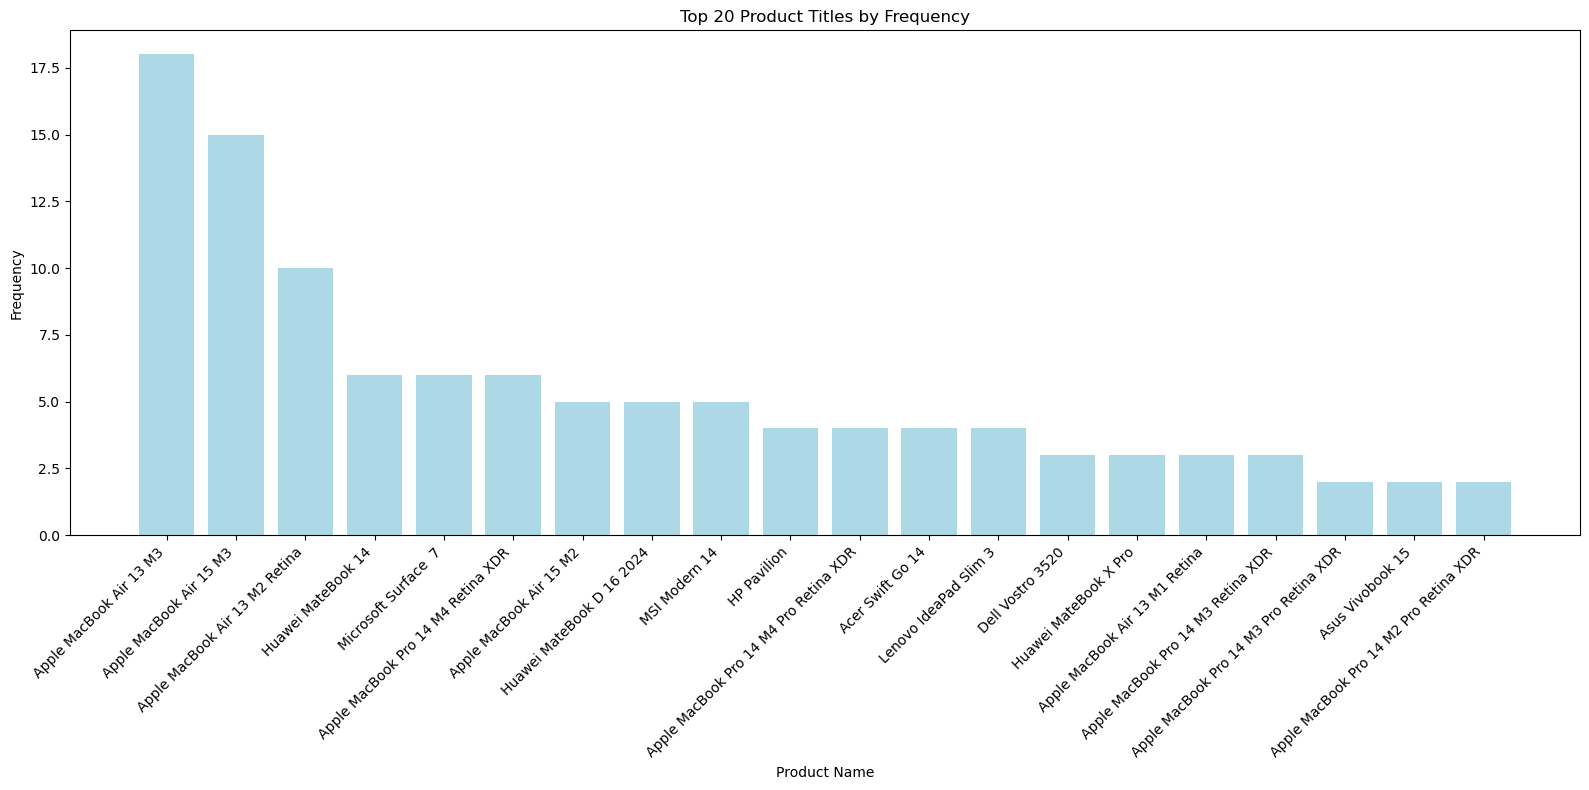

In [206]:
# Creating a bar chart to visualize the frequency distribution of 'Product Title'
plt.figure(figsize=(16, 8))
product_title_counts = df['Product Name'].value_counts().head(20)  # Displaying the top 20 most frequent titles

# Bar chart for Product Title
plt.bar(product_title_counts.index, product_title_counts.values, color='lightblue')
plt.title('Top 20 Product Titles by Frequency')
plt.xlabel('Product Name')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- Bivariate Analysis with the Target Variable (SalePrice)

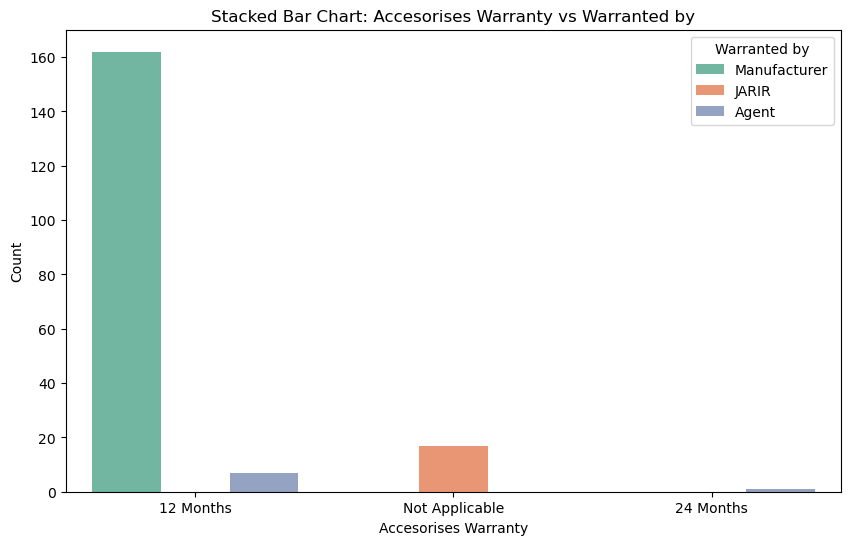

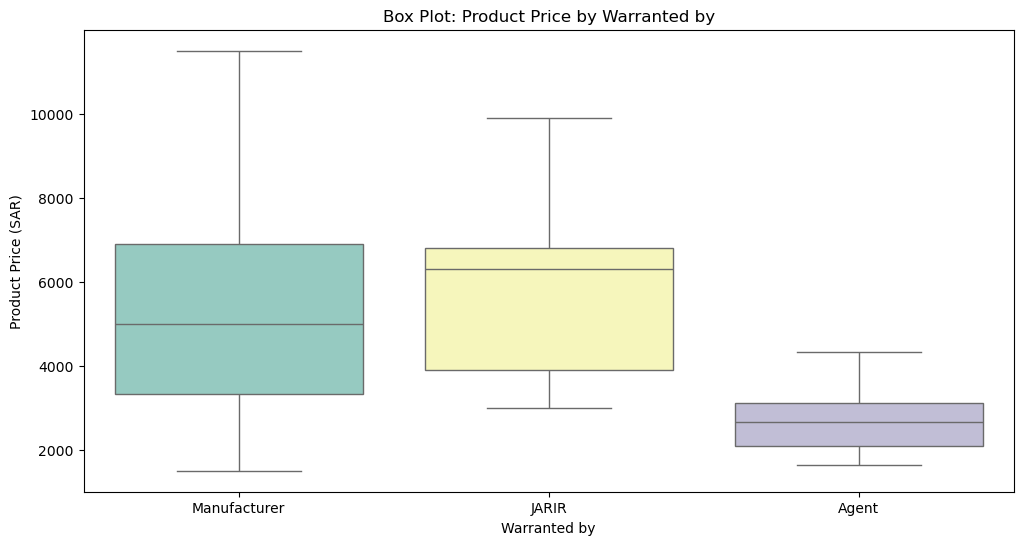

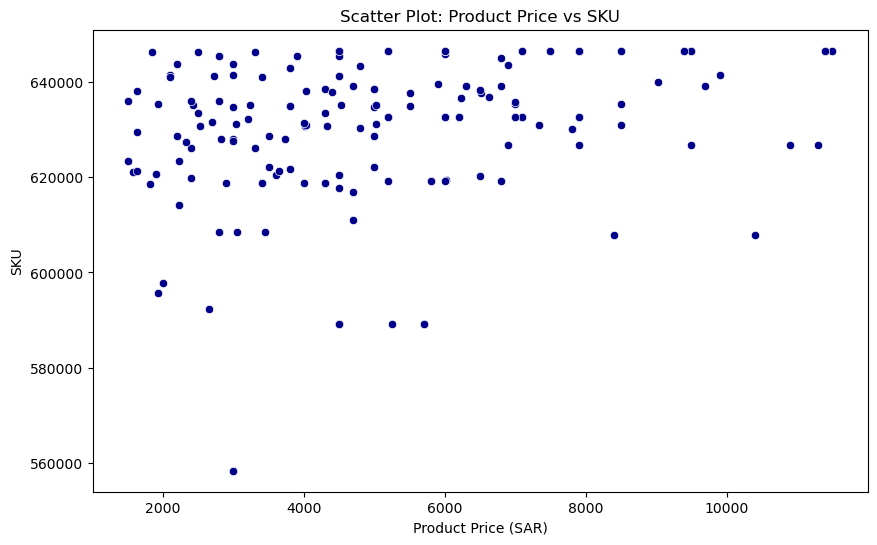

In [208]:
# Bivariate Analysis Code Examples

# 1. Categorical & Categorical: Stacked Bar Chart
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Accesorises warranty', hue='Warranted by', palette='Set2')
plt.title('Stacked Bar Chart: Accesorises Warranty vs Warranted by')
plt.xlabel('Accesorises Warranty')
plt.ylabel('Count')
plt.legend(title='Warranted by')
plt.show()

# 2. Categorical & Numerical: Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Warranted by', y='Product Price', palette='Set3')
plt.title('Box Plot: Product Price by Warranted by')
plt.xlabel('Warranted by')
plt.ylabel('Product Price (SAR)')
plt.show()

# 3. Numerical & Numerical: Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Product Price', y='SKU', color='darkblue')
plt.title('Scatter Plot: Product Price vs SKU')
plt.xlabel('Product Price (SAR)')
plt.ylabel('SKU')
plt.show()


In [209]:
df

,Product Name,Product Price,Warranty Period (Months),Accesorises warranty,Warranted by,SKU,Manufacturer Number,processor type,NPU (Neural Processing Unit),AI (Artificial Intelligence),...,cam resolution,multimedia features,special features,fingerprint,battery type,width,height/length,depth,weight,card reader
0,Huawei MateBook 14,4299,24.0,12 Months,Manufacturer,638525.0,53014ASK,Intel Core Ultra 5 125H,Intel AI Boost,Yes,...,FHD (2 MP) Webcam,Built-in Mic/Speakers,Full Size Keyboard,Yes,Lithium Polymer (Li-Po),312.60 mm ( 12.31 in ),226.80 mm ( 8.93 in ),15.90 mm ( .63 in ),1.31 kg ( 2.89 lb ),No
1,Apple MacBook Air 15 M3,5999,24.0,12 Months,Manufacturer,646475.0,MC9D4ABA,M3 8-core CPU,16-core Neural Engine,Yes,...,1080p FaceTime HD Camera,Built-in Mic/Speakers,Not Applicable,Yes,Lithium Polymer (Li-Po),34.04 cm ( 13.40 in ),23.76 cm ( 9.35 in ),1.15 cm ( .45 in ),1.51 kg ( 3.33 lb ),No
2,Apple MacBook Air 15 M3,5999,24.0,12 Months,Manufacturer,632673.0,MRYR3ABA,M3 8-core CPU,16-core Neural Engine,Yes,...,1080p FaceTime HD Camera,Built-in Mic/Speakers,Not Applicable,Yes,Lithium Polymer (Li-Po),34.04 cm ( 13.40 in ),23.76 cm ( 9.35 in ),1.15 cm ( .45 in ),1.51 kg ( 3.33 lb ),No
3,Asus,3799,24.0,12 Months,Manufacturer,642879.0,UM3406OLEDR7W,AMD Ryzen 7-8840HS,AMD XDNA up to 16 TOPS,Yes,...,1080P FHD Camera,Harman Kardon,Backlit Chiclet Keyboard,Yes,Lithium Ion (Li-Ion) - 4 Cell,32.24 cm ( 12.69 in ),22.01 cm ( 8.67 in ),1.49 cm ( .59 in ),1.20 kg ( 2.65 lb ),Yes
4,Microsoft Surface 7,9699,24.0,Not Applicable,JARIR,639206.0,ZHI00014,Snapdragon X Elite 12 Core,Qualcomm Hexagon NPU 45 TOPS,Yes,...,1080P FHD Camera,Not Applicable,CoPilot+,No,Lithium Ion (Li-Ion) - 6 Cell,32.90 cm ( 12.95 in ),23.90 cm ( 9.41 in ),1.80 cm ( .71 in ),1.60 kg ( 3.53 lb ),No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,Apple MacBook Air 13 M3,5199,24.0,12 Months,Manufacturer,646468.0,MC8J4ABA,M3 8-core CPU,16-core Neural Engine,Yes,...,1080p FaceTime HD Camera,Built-in Mic/Speakers,Not Applicable,Yes,Lithium Polymer (Li-Po),30.41 cm ( 11.97 in ),21.50 cm ( 8.46 in ),1.10 cm ( .43 in ),1.24 kg ( 2.73 lb ),No
201,Lenovo IdeaPad Pro 5,5029,24.0,12 Months,Manufacturer,631066.0,83D4004NAD,Intel Core Ultra 7 155H,Not Applicable,No,...,FHD 1080p + IR with Privacy Shutter,"Dolby Atmos Sound System, (2 X 2W) Speakers","High Definition Audio, Realtek ALC3287 Codec, ...",No,Lithium Polymer (Li-Po),35.60 cm ( 14.02 in ),25.10 cm ( 9.88 in ),1.75 cm ( .69 in ),1.94 kg ( 4.28 lb ),Yes
202,Huawei MateBook D 14,2799,24.0,12 Months,Manufacturer,608551.0,NBDEWDH9,Intel Core i5-1155G7 (11th Gen),Not Applicable,No,...,720P HD Recessed Camera,2 X 2W Speakers,"Low Blue Light, Flicker Free",Yes,Lithium Polymer (Li-Po) - 4 Cell,32.25 cm ( 12.70 in ),21.48 cm ( 8.46 in ),1.59 cm ( .63 in ),1.38 kg ( 3.04 lb ),No
203,Dell Vostro 3520,2499,24.0,12 Months,Manufacturer,646301.0,VOSTROI5,Intel Core i5-1235U (12th Gen),Not Applicable,No,...,720p HD Camera,Built-in Dual Stereo Speakers,Not Applicable,Yes,Lithium Ion (Li-Ion) - 3 Cell,35.85 cm ( 14.11 in ),23.56 cm ( 9.28 in ),2.25 cm ( .89 in ),1.66 kg ( 3.66 lb ),Yes


In [210]:
df['Product Price'].dtype

dtype('int64')

In [211]:
df.drop(columns=["Accesorises warranty", "Warranted by" , "ports"], inplace=True)


In [212]:
df.rename(columns={"RAM": "RAM(GB)"}, inplace=True)

# Remove the text "RAM" from the data
df["RAM(GB)"] = df["RAM(GB)"].str.replace("GB RAM", "", regex=False).str.strip()

In [213]:
df.head

<bound method NDFrame.head of                 Product Name  Product Price  Warranty Period (Months)  \
0         Huawei MateBook 14           4299                      24.0   
1    Apple MacBook Air 15 M3           5999                      24.0   
2    Apple MacBook Air 15 M3           5999                      24.0   
3                       Asus           3799                      24.0   
4       Microsoft Surface  7           9699                      24.0   
..                       ...            ...                       ...   
200  Apple MacBook Air 13 M3           5199                      24.0   
201     Lenovo IdeaPad Pro 5           5029                      24.0   
202     Huawei MateBook D 14           2799                      24.0   
203         Dell Vostro 3520           2499                      24.0   
204  Apple MacBook Air 15 M2           5799                      24.0   

          SKU Manufacturer Number                       processor type  \
0    638525.0      

In [214]:
df["RAM(GB)"]

0      16
1      16
2       8
3      16
4      32
       ..
200    16
201    16
202     8
203     8
204     8
Name: RAM(GB), Length: 187, dtype: object

In [215]:
df.drop(columns=["NPU (Neural Processing Unit)"], inplace=True)

In [216]:
df.columns

Index(['Product Name', 'Product Price', 'Warranty Period (Months)', 'SKU',
       'Manufacturer Number', 'processor type', 'AI (Artificial Intelligence)',
       'display type', 'graphics card', 'display size', 'operating system',
       'product type', 'model series', 'generation/release', 'color',
       'operating system architecture', 'processor speed', 'capacity',
       'RAM(GB)', 'connectivity technology', 'touch display',
       'display resolution', 'cam resolution', 'multimedia features',
       'special features', 'fingerprint', 'battery type', 'width',
       'height/length', 'depth', 'weight', 'card reader'],
      dtype='object')

In [217]:
# Dropping the columns that your friend dropped, but only if they exist in your DataFrame
columns_to_drop = [
    'Display Type', 'Speakers Type', 'Part Number', 'Ports',
    'Processor Speed', 'Microphone Type', 'Response Time', 'Fingerprint Type',
    'Neural Processing', 'Keyboard type', 'Sync Technology', 'Refresh Rate',
    'Features', 'Display Technology', 'Panel Backlight', 'DVD Reader',
    'Rear Camera', 'Fingerprint', 'Card Reader', 'Ethernet Port', 'Accessories',
    'Microsoft Office', 'keyboard language', 'Mobile broadband',
    'High Dynamic Range', 'User Guide'
]

# Dropping columns that exist in the DataFrame
df = df.drop([col for col in columns_to_drop if col in df.columns], axis=1)

# Display the updated columns in the DataFrame
df.columns


Index(['Product Name', 'Product Price', 'Warranty Period (Months)', 'SKU',
       'Manufacturer Number', 'processor type', 'AI (Artificial Intelligence)',
       'display type', 'graphics card', 'display size', 'operating system',
       'product type', 'model series', 'generation/release', 'color',
       'operating system architecture', 'processor speed', 'capacity',
       'RAM(GB)', 'connectivity technology', 'touch display',
       'display resolution', 'cam resolution', 'multimedia features',
       'special features', 'fingerprint', 'battery type', 'width',
       'height/length', 'depth', 'weight', 'card reader'],
      dtype='object')

In [218]:
df.shape

(187, 32)

In [219]:
# Renaming 'display size' to 'Screen size (inch)'
df = df.rename(columns={'display size': 'Screen size (inch)'})
# Removing the double quotes from the 'Screen size (inch)' values and converting to float
df['Screen size (inch)'] = df['Screen size (inch)'].str.replace('"', '').astype(float)

# Displaying the updated columns to confirm the change
df['Screen size (inch)']


0      14.2
1      15.3
2      15.3
3      14.0
4      15.0
       ... 
200    13.6
201    16.0
202    14.0
203    15.6
204    15.3
Name: Screen size (inch), Length: 187, dtype: float64

In [220]:
# Dropping the specified columns from the DataFrame
columns_to_drop = [
    'graphics card', 'card reader', 'fingerprint',
    'multimedia features', 'special features', 'processor speed'
]

# Dropping the columns
df = df.drop(columns=columns_to_drop, axis=1)

# Displaying the updated columns to confirm the changes
df.columns


Index(['Product Name', 'Product Price', 'Warranty Period (Months)', 'SKU',
       'Manufacturer Number', 'processor type', 'AI (Artificial Intelligence)',
       'display type', 'Screen size (inch)', 'operating system',
       'product type', 'model series', 'generation/release', 'color',
       'operating system architecture', 'capacity', 'RAM(GB)',
       'connectivity technology', 'touch display', 'display resolution',
       'cam resolution', 'battery type', 'width', 'height/length', 'depth',
       'weight'],
      dtype='object')

In [221]:
df.shape

(187, 26)

In [222]:
# Dropping the columns that are not in your friend's list
df = df.drop(columns=[
    'SKU', 'Manufacturer Number', 'AI (Artificial Intelligence)',
    'display type', 'model series', 'generation/release', 'operating system architecture',
    'cam resolution', 'width','height/length', 'depth', 'weight'
])

# Displaying the updated columns to confirm
df.columns


Index(['Product Name', 'Product Price', 'Warranty Period (Months)',
       'processor type', 'Screen size (inch)', 'operating system',
       'product type', 'color', 'capacity', 'RAM(GB)',
       'connectivity technology', 'touch display', 'display resolution',
       'battery type'],
      dtype='object')

In [223]:
df.shape

(187, 14)

In [224]:
df.columns

Index(['Product Name', 'Product Price', 'Warranty Period (Months)',
       'processor type', 'Screen size (inch)', 'operating system',
       'product type', 'color', 'capacity', 'RAM(GB)',
       'connectivity technology', 'touch display', 'display resolution',
       'battery type'],
      dtype='object')

In [225]:
df.columns.tolist()

['Product Name',
 'Product Price',
 'Warranty Period (Months)',
 'processor type',
 'Screen size (inch)',
 'operating system',
 'product type',
 'color',
 'capacity',
 'RAM(GB)',
 'connectivity technology',
 'touch display',
 'display resolution',
 'battery type']

In [226]:
df.rename(columns={"processor type": "Product Type"}, inplace=True)
df.rename(columns={"color": "Color"}, inplace=True)
df.rename(columns={"Warranty Period (Months)":"Warranty Period(Months)"}, inplace=True)
df.rename(columns={"Product Price": "Product Price"}, inplace=True)
df.rename(columns={"Product Type": "Processor Type"}, inplace=True)
df.rename(columns={"Screen size (inch)": "Screen Size(inch)"}, inplace=True)
df.rename(columns={"operating system": "Operating System"}, inplace=True)
df.rename(columns={"capacity": "Storage Capacity"}, inplace=True)
df.rename(columns={"RAM(GB)": "RAM(GB)"}, inplace=True)
df.rename(columns={"connectivity technology": "Network and Communication"}, inplace=True)
df.rename(columns={"touch display": "Touch Display"}, inplace=True)
df.rename(columns={"display resolution": "Display Resolution"}, inplace=True)
df.rename(columns={"battery type": "Battery Type"}, inplace=True)


In [227]:
df.columns.tolist()

['Product Name',
 'Product Price',
 'Warranty Period(Months)',
 'Processor Type',
 'Screen Size(inch)',
 'Operating System',
 'product type',
 'Color',
 'Storage Capacity',
 'RAM(GB)',
 'Network and Communication',
 'Touch Display',
 'Display Resolution',
 'Battery Type']

In [228]:
df

,Product Name,Product Price,Warranty Period(Months),Processor Type,Screen Size(inch),Operating System,product type,Color,Storage Capacity,RAM(GB),Network and Communication,Touch Display,Display Resolution,Battery Type
0,Huawei MateBook 14,4299,24.0,Intel Core Ultra 5 125H,14.2,Windows 11 Home,Laptop,Space Grey,1 TB M.2 NVMe PCIe 4.0 SSD,16,Wi-Fi (6)/Bluetooth (5.1),Yes,2880 X 1920,Lithium Polymer (Li-Po)
1,Apple MacBook Air 15 M3,5999,24.0,M3 8-core CPU,15.3,macOS Sequoia,Laptop,Space Grey,256 GB SSD,16,Wi-Fi/Bluetooth,No,2880 X 1864,Lithium Polymer (Li-Po)
2,Apple MacBook Air 15 M3,5999,24.0,M3 8-core CPU,15.3,macOS Sonoma,Laptop,Starlight,256 GB SSD,8,Wi-Fi/Bluetooth,No,2880 X 1864,Lithium Polymer (Li-Po)
3,Asus,3799,24.0,AMD Ryzen 7-8840HS,14.0,Windows 11,Laptop,Jade Black,1 TB M.2 NVMe PCIe 4.0 SSD,16,Wi-Fi/Bluetooth,No,1920 X 1200 (WUXGA),Lithium Ion (Li-Ion) - 4 Cell
4,Microsoft Surface 7,9699,24.0,Snapdragon X Elite 12 Core,15.0,Windows 11 Home,Laptop,Black,1 TB SSD,32,Wi-Fi (7)/Bluetooth (5.4),Yes,2496 x 1664,Lithium Ion (Li-Ion) - 6 Cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,Apple MacBook Air 13 M3,5199,24.0,M3 8-core CPU,13.6,macOS Sequoia,Laptop,Starlight,256 GB SSD,16,Wi-Fi/Bluetooth,No,2560 X 1664,Lithium Polymer (Li-Po)
201,Lenovo IdeaPad Pro 5,5029,24.0,Intel Core Ultra 7 155H,16.0,Windows 11 Home,Laptop,Arctic Grey,512 GB NVMe M.2 SSD,16,Wi-Fi (6E)/Bluetooth (5.2),No,2048 X 1280,Lithium Polymer (Li-Po)
202,Huawei MateBook D 14,2799,24.0,Intel Core i5-1155G7 (11th Gen),14.0,Windows 11,Laptop,Mystic Silver,512 GB NVMe M.2 SSD,8,Wi-Fi/Bluetooth,No,1920 X 1080 (FHD),Lithium Polymer (Li-Po) - 4 Cell
203,Dell Vostro 3520,2499,24.0,Intel Core i5-1235U (12th Gen),15.6,Windows 11 Home,Laptop,Carbon Black,512 GB NVMe M.2 SSD,8,Wi-Fi/Bluetooth,No,1920 X 1080 (FHD),Lithium Ion (Li-Ion) - 3 Cell


In [229]:
# Printing current columns to check for differences
print(df.columns)


Index(['Product Name', 'Product Price', 'Warranty Period(Months)',
       'Processor Type', 'Screen Size(inch)', 'Operating System',
       'product type', 'Color', 'Storage Capacity', 'RAM(GB)',
       'Network and Communication', 'Touch Display', 'Display Resolution',
       'Battery Type'],
      dtype='object')


In [230]:
df.to_csv('cleaned_Jarir_laptops.csv', index=False)